In [6]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [7]:
winner_df = tourney_df[['Winner', 'Probability']].groupby('Winner').sum()
winner_df.sort_values(by='Probability', ascending=False)


,Probability
Winner,
Nathan Sanches,0.163619
Patrick Commers,0.140068
Tyler Krause,0.126473
Ian Thorpe,0.117852
George Wright,0.093397
Bobby Ingram,0.082649
Serigne Diaw,0.059597
Koy Kubasta,0.050107
Keith Schneider,0.035085


In [8]:
from math import pi, cos, sin, sqrt, gcd

def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        floor += (1 - floor) / n
        k = 1 - floor
        x, y, z = xyz        
    return colors

grouped_df = (tourney_df[['Winner','Probability']].groupby('Winner')
              .sum().sort_values('Probability', ascending = False))
labels = list(grouped_df.index) + ['Other']

n = len(labels)
step = 2
while gcd(step, n) > 1:
    step += 1

floor = 0.1
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(labels, colors)}
color_dict

{'Nathan Sanches': [0.22426406871192844,
  0.9340716898472599,
  0.41445644757659683],
 'Patrick Commers': [0.12171819331190228,
  0.7559388726038767,
  0.729116278169154],
 'Tyler Krause': [0.2401993414912975, 0.4714841218246486, 0.92826194400506],
 'Ian Thorpe': [0.5132529395976787, 0.23988768031635027, 0.9191870396136199],
 'George Wright': [0.7967656504482555, 0.1851239117675197, 0.7220493435135964],
 'Bobby Ingram': [0.947813978350257, 0.3329372905100507, 0.4540462343516977],
 'Serigne Diaw': [0.8991819982301863, 0.6020353047676841, 0.26370406918527795],
 'Koy Kubasta': [0.6908722631741349, 0.8515423671500244, 0.25191337585462836],
 'Keith Schneider': [0.44419259773889, 0.957308391501646, 0.4215334929816138],
 'Mark Hurst': [0.2946409572376397, 0.8759002618834403, 0.6805162516195902],
 'Dan Wros': [0.3205444086845176, 0.6634681075532778, 0.8944007290090492],
 'Danny Ryan': [0.5048847196998048, 0.4417661190726576, 0.958466853016124],
 'Justin Calvillo': [0.7486666055412219,
  0.331

In [15]:
teams = ['Arkansas',
         'Arizona',
         'Texas',
         'Purdue',
         'Illinois',
         'Houston',
         'Iowa',
         'Nebraska']

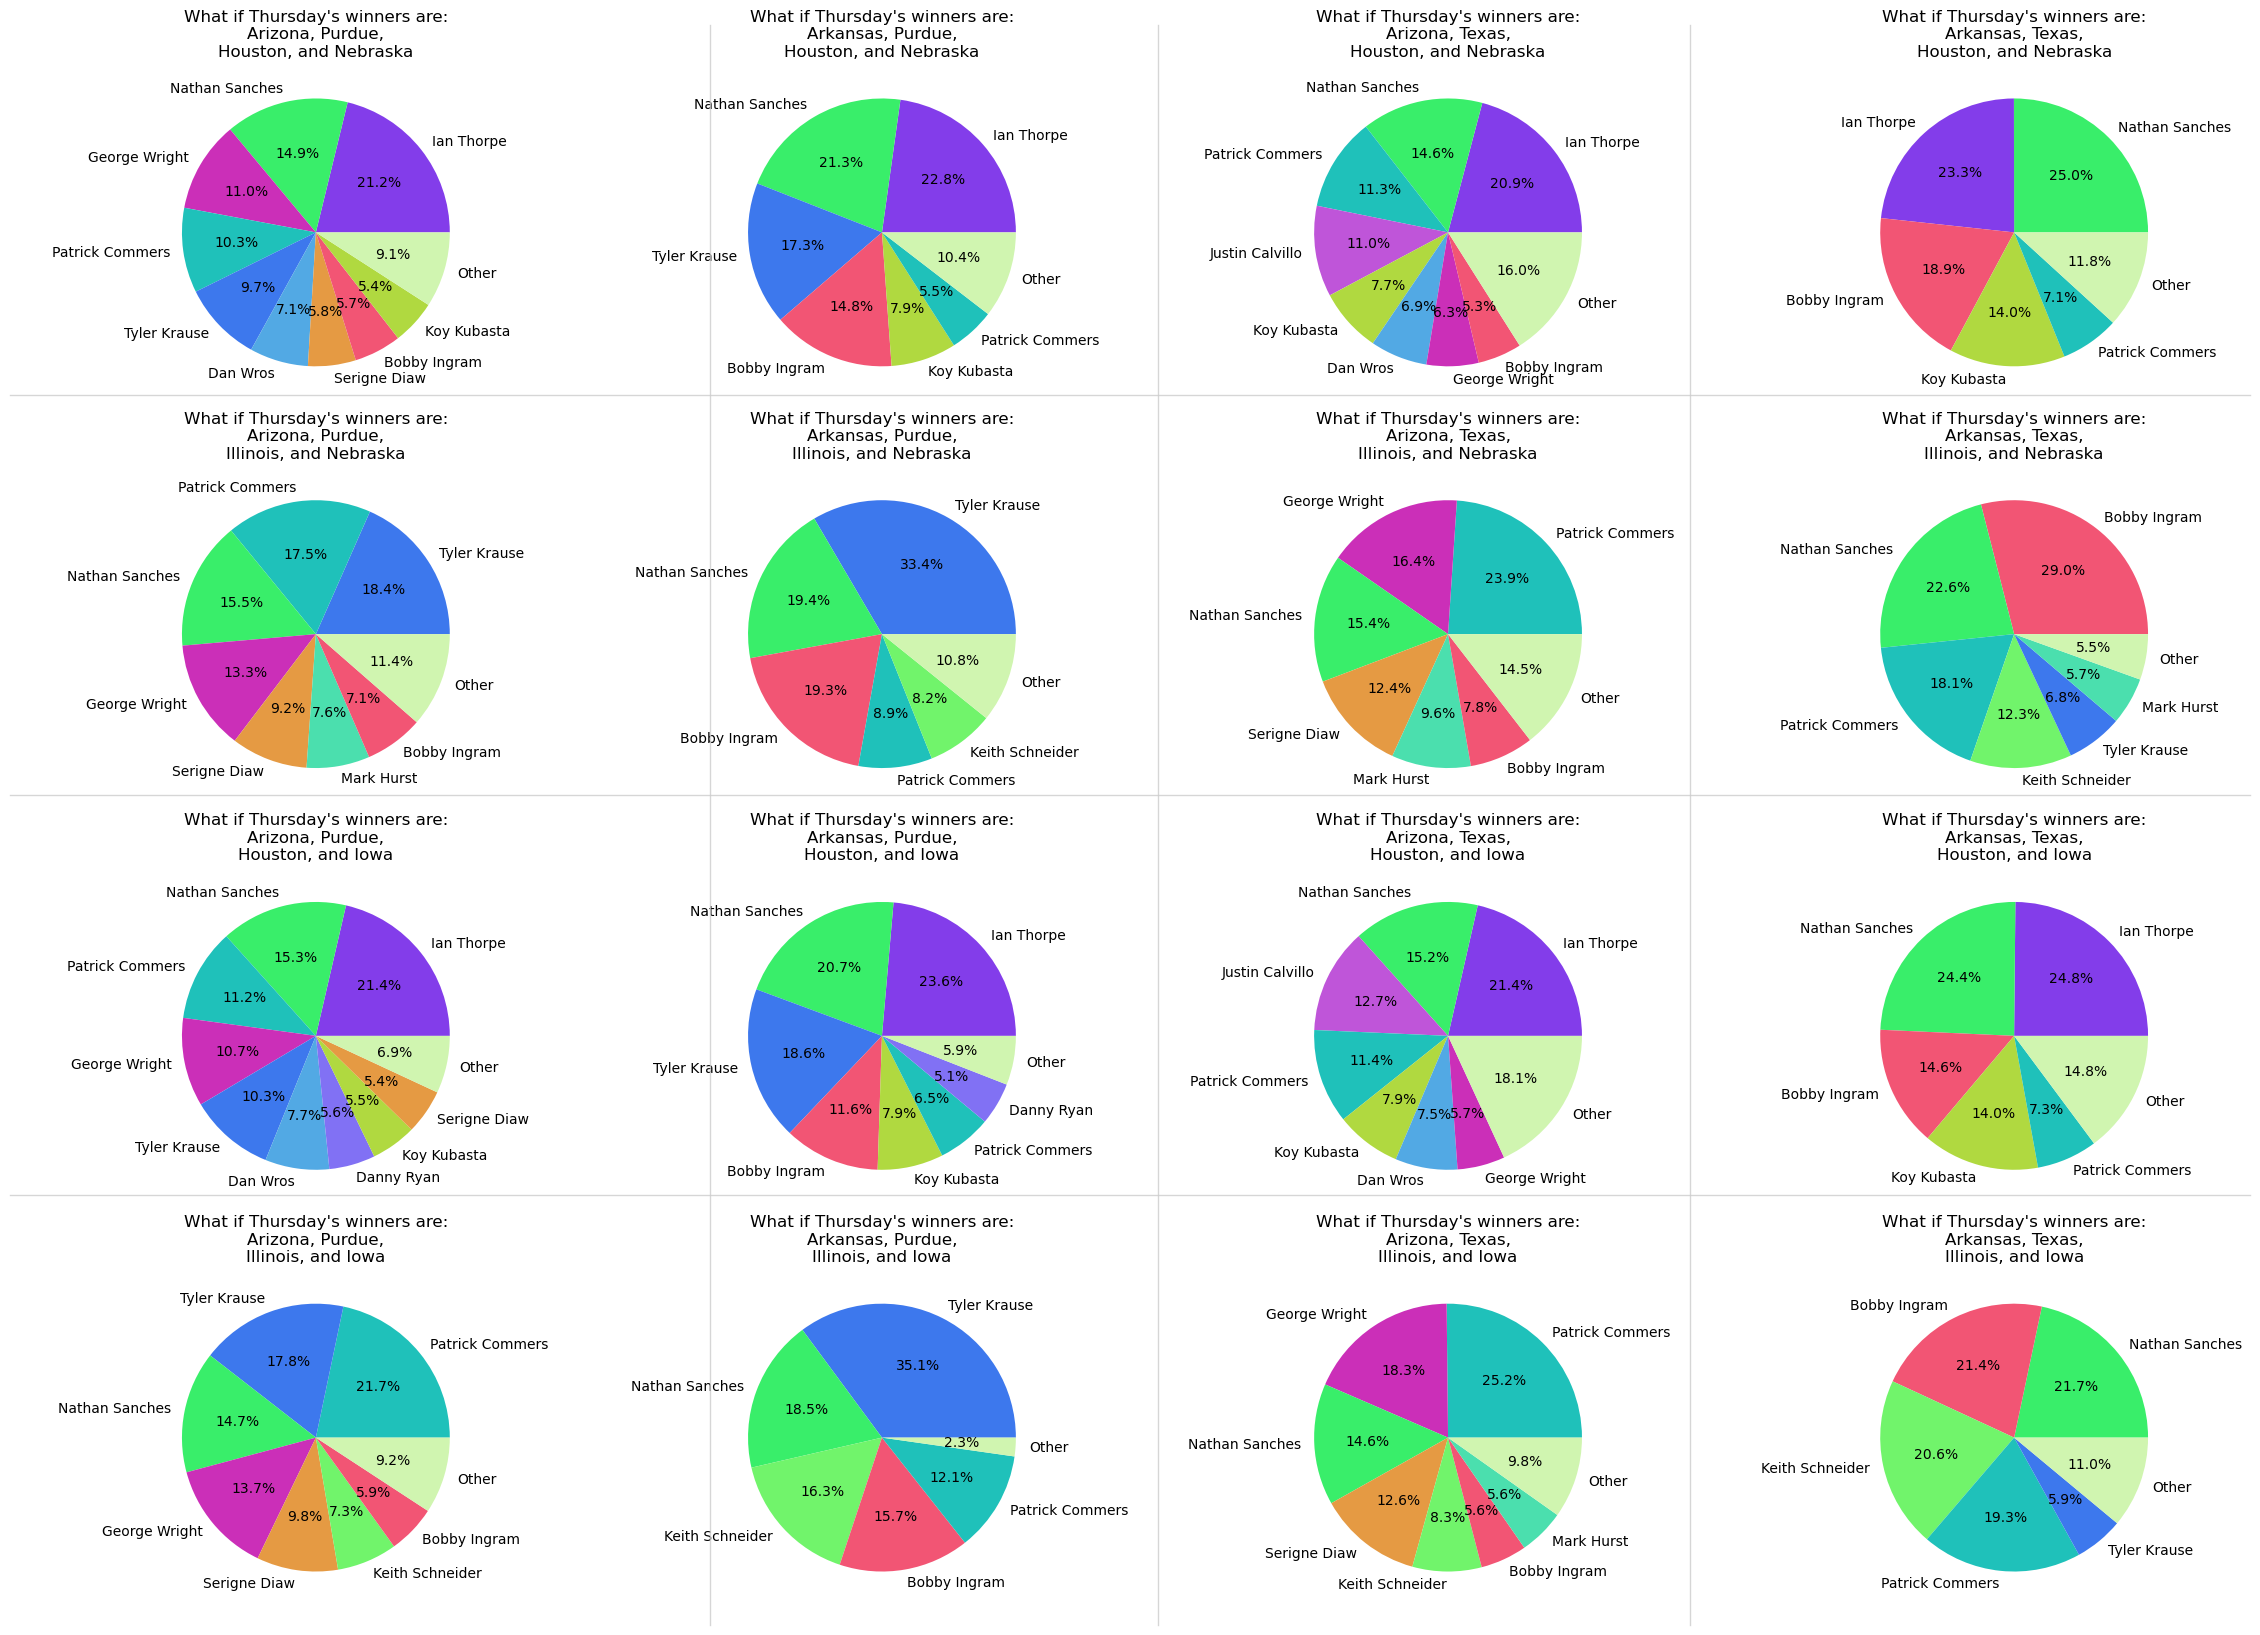

In [18]:
dfs = []
all_labels = []
disp_titles = []

fig, axs = plt.subplots(4, 4, figsize = [28,20])
for ax, vec in zip(axs.flatten(), range(15, -1, -1)):
    results = [(vec>>j) % 2 for j in range(4)]
    winners = [teams[2 * a + b] for a, b in zip(range(4), results)]
    sub_df = tourney_df.loc[(tourney_df[winners[0]] > 2) &
                            (tourney_df[winners[1]] > 2) &
                            (tourney_df[winners[2]] > 2) &
                            (tourney_df[winners[3]] > 2)]
    grouped_df = sub_df[['Winner','Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
    grouped_df['Win Probability'] = grouped_df['Probability']/grouped_df['Probability'].sum()
    grouped_df = grouped_df[['Win Probability']]
    grouped_df = grouped_df.loc[grouped_df['Win Probability'] > 0.05]
    other = 1.0 - grouped_df['Win Probability'].sum()
    if other > 0.0001:
        grouped_df.loc['Other'] = [other]
    title = f"""What if Thursday's winners are:
{winners[0]}, {winners[1]},
{winners[2]}, and {winners[3]}"""
    labels = list(grouped_df.index)
    colors = [color_dict[label] for label in labels]
    ax.pie(grouped_df['Win Probability'], 
           labels=grouped_df.index,
           normalize=True,
           autopct='%1.1f%%',
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')



line = plt.Line2D((0.1, 0.9),(0.715, 0.715), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.1, 0.9),(0.515, 0.515), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.1, 0.9),(0.315, 0.315), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.315, 0.315),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.515, 0.51),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.71, 0.71),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

plt.savefig('plots/thursday_what_if.png', dpi=300, bbox_inches='tight')

